# Overview

This script is designed to perform a series of simulations using SWMM (Storm Water Management Model) with different rain shift scenarios.  
It processes storm data, updates time series inputs for each simulation, runs the SWMM model, and extracts key results from the output.  
The script supports multiple event types, such as 'historical' and 'future', and calculates various metrics including outflows, rainfall intensities, and runoff coefficients for different storm events.  
It also includes functionalities for dynamically adjusting the input files based on specific spatial shifts (`x_shift`, `y_shift`) to simulate different rain patterns and observe their impact on runoff.  
Results are collected, processed, and stored in a DataFrame with a MultiIndex structure for easy analysis. The final results are saved in a pickle file for further use.

## Key Components:
- **Data Loading**: Loads the SWMM output file and parses it into a DataFrame for analysis.
- **Rain Shift Processing**: Reads rain shift text files and updates the time series data in the SWMM input file accordingly.
- **Statistical Analysis**: Computes key metrics like total outflow, rainfall intensities, and runoff coefficients based on the storm data.
- **Result Storage**: Results are stored in a structured DataFrame with hierarchical column names and saved in a pickle file.

The script is organized to handle multiple combinations of spatial shifts, event types, and storm scenarios, making it adaptable to different simulation needs.


## Imports and files

In [1]:
import os
import pickle
import re
import itertools

# Date and time related imports
from datetime import datetime, timedelta

# Scientific libraries
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.interpolate import griddata

# Geospatial libraries
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Polygon, Point

# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D

# SWMM related imports
from swmm_api.input_file import read_inp_file, SwmmInput, section_labels as sections
from swmm_api import read_out_file, read_rpt_file, swmm5_run, SwmmReport

## Functions

In [2]:
def load_sim_to_df(sim_output_path):
    """
    Takes SWMM FILE with outflow data and makes pd Dataframe.
    Includes both system-level data (outflow and rainfall) and subcatchment-level rainfall data.

    Args:
        sim_output_path (str): File name containing SWMM outflow data.

    Returns:
        pd.DataFrame: Combined dataframe with system-level and subcatchment-level data.
    """
    # System-level data
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['outflow', 'rainfall']]  # area weighted over all subcatchments
    sim_df.rename(columns={'outflow': 'SWMM outflow [CMS]', 'rainfall': 'Basin rainfall [mm/hr]'}, inplace=True, errors='raise')

    # Subcatchment-level rainfall data
    outfile_df = read_out_file(sim_output_path).to_frame()['subcatchment']
    rainfall_by_subcatchment = outfile_df.xs('rainfall', level=1, axis=1)

    # Combine both into a single dataframe
    sim_df = pd.concat([sim_df, rainfall_by_subcatchment], axis=1)

    # Ensure index is in datetime format
    sim_df.index = pd.to_datetime(sim_df.index)

    return sim_df


In [3]:
def read_rain_shift_txt_file(rain_shift_directory_path, x_shift, y_shift):
    # List all files in the directory
    files_in_directory = os.listdir(rain_shift_directory_path)

    # Filter files with the desired format
    matching_files = [file for file in files_in_directory if "rain_shift_" in file]

    if not matching_files:
        print("No matching files found.")
        return None, None, None

    # Find the file that matches the specified x_shift and y_shift
    x_shift_str = str(abs(x_shift))
    y_shift_str = str(abs(y_shift))
    matching_file = None
    for file in matching_files:
        x_match = re.search(r'x(plus|minus)_(\d+)', file)
        y_match = re.search(r'y(plus|minus)_(\d+)', file)
        
        if x_match and y_match:
            file_x_shift = int(x_match.group(2)) * (1 if x_match.group(1) == 'plus' else -1)
            file_y_shift = int(y_match.group(2)) * (1 if y_match.group(1) == 'plus' else -1)
            if file_x_shift == x_shift and file_y_shift == y_shift:
                matching_file = file
                break

    if not matching_file:
        print(f"No file found with x_shift: {x_shift} and y_shift: {y_shift}")
        return None, None, None

    # Construct the file path
    file_path = os.path.join(rain_shift_directory_path, matching_file)

    # Open and read the contents of the matched file
    with open(file_path, 'r') as file:
        rain_shift_txt = file.read()

    # Return x_shift, y_shift, and file_contents
    return rain_shift_txt

In [4]:
def parse_date_time(row):
    """
    Parse date and time from a formatted row.
    """
    columns = row.split()
    date_str = columns[1]
    time_str = columns[2]
    date = datetime.strptime(date_str, '%m/%d/%Y').date()
    time = datetime.strptime(time_str, '%H:%M:%S').time()
    return date, time

def update_TimeSeriesData(inp, timeseries_text):
    """
    Update the time series data in an input file used for simulation.
    
    Args:
    - inp (dict): Dictionary containing simulation input data.
    - timeseries_text (str): Text containing transformed time series data.
    
    Returns:
    - None
    """
    lines = timeseries_text.strip().split('\n')
    data_rows = [line for line in lines if not line.startswith(';;')]
    
    # Parse the first and last data rows for start and end times
    first_date, first_time = parse_date_time(data_rows[0])
    second_date, second_time = parse_date_time(data_rows[1])
    last_date, last_time = parse_date_time(data_rows[-1])
    
    first_datetime = datetime.combine(first_date, first_time)
    second_datetime = datetime.combine(second_date, second_time)
    
    # Calculate time interval between the first and second rows
    first_timedelta = timedelta(hours=first_time.hour, minutes=first_time.minute, seconds=first_time.second)
    second_timedelta = timedelta(hours=second_time.hour, minutes=second_time.minute, seconds=second_time.second)
    
    # Calculate the difference
    time_interval = str(second_timedelta - first_timedelta)
    
    # Calculate start and end times
    start_datetime = datetime.combine(first_date, first_time)
    if start_datetime.hour < 6:
        start_datetime -= timedelta(days=1)
    START_DATE = start_datetime.date()
    REPORT_START_DATE = START_DATE
    START_TIME = (start_datetime - timedelta(hours=6)).time()
    REPORT_START_TIME = START_TIME
    
    end_datetime = datetime.combine(last_date, last_time)
    if end_datetime.hour >= 18:
        end_datetime += timedelta(days=1)
    END_DATE = end_datetime.date()
    END_TIME = (end_datetime + timedelta(hours=6)).time()
    
    # Update the options section with calculated times
    inp['OPTIONS']['START_DATE'] = START_DATE
    inp['OPTIONS']['START_TIME'] = START_TIME
    inp['OPTIONS']['REPORT_START_DATE'] = REPORT_START_DATE
    inp['OPTIONS']['REPORT_START_TIME'] = REPORT_START_TIME
    inp['OPTIONS']['END_DATE'] = END_DATE
    inp['OPTIONS']['END_TIME'] = END_TIME
    
    # Update the time series section with new data
    inp['TIMESERIES'] = timeseries_text

    # Ensure that the number of time series matches the number of rain gauges
    if len(inp['TIMESERIES'].keys()) != len(inp['RAINGAGES'].keys()):
        raise ValueError('ERROR: The number of time series does not match the number of rain gauges.')

    # Edit the time series name and its corresponding rain gauge field
    for basin_timeserie in range(len(list(inp['TIMESERIES'].keys()))):
        basin_timeserie_name = inp['TIMESERIES'][list(inp['TIMESERIES'].keys())[basin_timeserie]]['name']
        inp['RAINGAGES'][list(inp['RAINGAGES'].keys())[basin_timeserie]]['timeseries'] = basin_timeserie_name
        inp['RAINGAGES'][list(inp['RAINGAGES'].keys())[basin_timeserie]]['interval'] = time_interval
        inp['RAINGAGES'][list(inp['RAINGAGES'].keys())[basin_timeserie]]['form'] = "INTENSITY"


In [5]:
def update_imperviousness_with_factor(subcatchment_dict, factor):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """


    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
#         initial_imperviousness = impervious_initial_values[index]
#         subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        if powered_imperviousness > 100:
            powered_imperviousness =100
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict

In [6]:
# Function to simplify the result extraction and store as a dictionary
def extract_simulation_stats(result):
    # Map the result tuple to a dictionary with keys based on the metric names
    metrics = [
            'swmm_total_outflow', 'swmm_max_outflow', 'swmm_max_outflow_time', 'runoff_coefficient',
            'max_10min_intensity_all', 'max_20min_intensity_all', 'max_30min_intensity_all', 'max_60min_intensity_all',
            'max_120min_intensity_all', 'max_240min_intensity_all', 'max_360min_intensity_all', 'max_720min_intensity_all', 
            'max_1440min_intensity_all', 'total_rain_all', 'max_10min_intensity_before_peak', 'max_20min_intensity_before_peak', 
            'max_30min_intensity_before_peak', 'max_60min_intensity_before_peak', 'max_120min_intensity_before_peak', 
            'max_240min_intensity_before_peak', 'max_360min_intensity_before_peak', 'max_720min_intensity_before_peak', 
            'max_1440min_intensity_before_peak', 'total_rain_before_peak', 'max_10min_intensity_subcatchment', 'max_20min_intensity_subcatchment',
            'max_30min_intensity_subcatchment', 'max_60min_intensity_subcatchment', 'max_120min_intensity_subcatchment', 
            'max_240min_intensity_subcatchment', 'max_360min_intensity_subcatchment', 'max_720min_intensity_subcatchment',
            'max_1440min_intensity_subcatchment', 'total_rain_subcatchment'
        ]

    
    # Return as a dictionary
    return dict(zip(metrics, result))

def simulation_stat(storm_df):
    """
    Format statistical data from storm_df DataFrame, assuming 10-minute intervals.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
                                     Must have columns ['SWMM outflow [CMS]', 'rainfall [mm/hr]'].
                                     The index should be datetime with 10-minute intervals.
    
    Returns:
        Tuple: Containing the calculated statistics as outlined in the docstring, including
               max rainfall intensity for each subcatchment based on rolling windows.
    """
    raanana_area = 13256.0  # Area in km² for runoff coefficient calculation
    # Ensure the index is datetime
    if not isinstance(storm_df.index, pd.DatetimeIndex):
        raise ValueError("The DataFrame index must be a DatetimeIndex.")
    
    # Total outflow volume [cubic meters]
    swmm_total_outflow = storm_df['SWMM outflow [CMS]'].sum() * 60 * 10  # 10-min interval assumed
    
    # Outflow peak [CMS] and time
    swmm_max_outflow = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_outflow_time = storm_df['SWMM outflow [CMS]'].idxmax()

    # Rainfall statistics for the entire storm
    rainfall_10min = storm_df['Basin rainfall [mm/hr]']  # Already at 10-minute intervals
    
    # Rolling windows including 1 (10-minute interval) and other larger windows
    rolling_windows = [1, 2, 3, 6, 12, 24, 36, 72, 144]  # Corresponds to 10 minutes, 20, 30, ..., 1440 minutes for 10-min data
    rolling_stats = {}
    
    # For 1, we can calculate max_10min_intensity directly
    rolling_stats["max_10min_intensity"] = rainfall_10min.max()
    
    # Calculate the rolling means for other windows and find the max of the rolling means
    for w in rolling_windows[1:]:  # Skip 1, already handled separately
        rolling_mean = rainfall_10min.rolling(window=w).mean()
        rolling_stats[f"max_{int(w*10)}min_intensity"] = rolling_mean.max()

    total_rain_all = storm_df['Basin rainfall [mm/hr]'].sum() / 6  # Convert mm/hr to mm for 10-min intervals

    # Filter data before the peak outflow time
    df_before_peak = storm_df[storm_df.index <= swmm_max_outflow_time]
    rainfall_10min_before_peak = df_before_peak['Basin rainfall [mm/hr]']
    max_10min_intensity_before_peak = rainfall_10min_before_peak.max()

    # Calculate rolling averages before peak (same as above, but only for data before peak)
    rolling_stats_before_peak = {}
    rolling_stats_before_peak["max_10min_intensity_before_peak"] = rainfall_10min_before_peak.max()

    for w in rolling_windows[1:]:  # Skip 1 for the before peak, already handled separately
        rolling_mean_before_peak = rainfall_10min_before_peak.rolling(window=w).mean()
        rolling_stats_before_peak[f"max_{int(w*10)}min_intensity_before_peak"] = rolling_mean_before_peak.max()
    
    total_rain_before_peak = df_before_peak['Basin rainfall [mm/hr]'].sum() / 6  # Convert mm/hr to mm

    # Subcatchment analysis: Find the maximum intensity for each subcatchment for each rolling window
    subcatchment_columns = [f'S{i:02d}' for i in range(1, 29)]  # Subcatchment names S01 to S28
    subcatchment_max_intensities = []

    max_total_rain_subcatchment = -np.inf
    subcatchment_with_max_total_rain = None

    for w in rolling_windows:
        max_intensity_value = -np.inf  # Initialize with a very low value
        subcatchment_with_max_intensity = None

        # Iterate through each subcatchment and calculate the rolling mean, then find the max of the means
        for subcatchment in subcatchment_columns:
            subcatchment_rainfall = storm_df[subcatchment]
            rolling_mean = subcatchment_rainfall.rolling(window=w).mean()
            max_mean_for_subcatchment = rolling_mean.max()

            # Check if this subcatchment has the highest max mean for this window
            if max_mean_for_subcatchment > max_intensity_value:
                max_intensity_value = max_mean_for_subcatchment
                subcatchment_with_max_intensity = subcatchment

        # Calculate total rain for the subcatchment
            total_rain_subcatchment = storm_df[subcatchment].sum() / 6  # Convert mm/hr to mm
            if total_rain_subcatchment > max_total_rain_subcatchment:
                max_total_rain_subcatchment = total_rain_subcatchment
                subcatchment_with_max_total_rain = subcatchment

        # Store the result for this rolling window
        subcatchment_max_intensities.append(max_intensity_value)
        
    # Runoff coefficient calculation: (swmm_total_outflow / raanana_area) / total_rain_all
    runoff_coefficient = (swmm_total_outflow / raanana_area) / total_rain_all 
    
    # Combine all results
    results = (
        swmm_total_outflow, swmm_max_outflow, swmm_max_outflow_time, runoff_coefficient,
        *rolling_stats.values(), total_rain_all,
        *rolling_stats_before_peak.values(), total_rain_before_peak,
        *subcatchment_max_intensities, max_total_rain_subcatchment)
    
    # Return results including subcatchment max intensities
    return results



In [7]:
def calculate_specific_discharge(rpt, inp):
    """
    Calculate specific discharge and related metrics for given SWMM report and input files.
    Returns a flat dictionary with combined keys.
    """
    subcatchment_areas_m2 = {sub: data['area'] * 10_000 for sub, data in inp["SUBCATCHMENTS"].items()}
    runoff_summary = rpt.subcatchment_runoff_summary

    # Calculate specific discharge
    runoff_summary['Specific_Discharge_m3/s/km2'] = runoff_summary.index.map(
        lambda sub: runoff_summary.loc[sub, 'Peak_Runoff_CMS'] / (subcatchment_areas_m2[sub] / 1_000_000)
    )

    def calculate_runoff_volume_m3(subcatchment):
        total_runoff_mm = runoff_summary.loc[subcatchment, 'Total_Runoff_mm']
        area_m2 = subcatchment_areas_m2[subcatchment]
        return (total_runoff_mm * area_m2) / 1_000  # Convert mm to m³

    max_specific = runoff_summary['Specific_Discharge_m3/s/km2'].idxmax()
    min_specific = runoff_summary['Specific_Discharge_m3/s/km2'].idxmin()
    most_urban = "S27"
    least_urban = "S28"

    # Flattened results dictionary
    results = {
        "Max_Specific_Discharge_Peak_Runoff_CMS": runoff_summary.loc[max_specific, 'Peak_Runoff_CMS'],
        "Max_Specific_Discharge_Total_Runoff_m3": calculate_runoff_volume_m3(max_specific),
        "Max_Specific_Discharge_Runoff_Coeff": runoff_summary.loc[max_specific, 'Runoff_Coeff'],

        "Min_Specific_Discharge_Peak_Runoff_CMS": runoff_summary.loc[min_specific, 'Peak_Runoff_CMS'],
        "Min_Specific_Discharge_Total_Runoff_m3": calculate_runoff_volume_m3(min_specific),
        "Min_Specific_Discharge_Runoff_Coeff": runoff_summary.loc[min_specific, 'Runoff_Coeff'],

        "Most_Urban_Peak_Runoff_CMS": runoff_summary.loc[most_urban, 'Peak_Runoff_CMS'],
        "Most_Urban_Total_Runoff_m3": calculate_runoff_volume_m3(most_urban),
        "Most_Urban_Runoff_Coeff": runoff_summary.loc[most_urban, 'Runoff_Coeff'],

        "Least_Urban_Peak_Runoff_CMS": runoff_summary.loc[least_urban, 'Peak_Runoff_CMS'],
        "Least_Urban_Total_Runoff_m3": calculate_runoff_volume_m3(least_urban),
        "Least_Urban_Runoff_Coeff": runoff_summary.loc[least_urban, 'Runoff_Coeff']
    }

    return results


# Run the shifts simulations

## In this code version u can utilize changes in imp % and define the future event with same storm values as the historic

In [8]:
def update_imperviousness_with_list(subcatchment_dict, factor, impervious_initial_values):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """


    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
        initial_imperviousness = impervious_initial_values[index]
        subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict

In [9]:
def calculate_basin_imp(inp):
    tot_area = 1325.6  # Ha
    tot_imp = 0
    subcatchments = inp['SUBCATCHMENTS']
    for sc in subcatchments.values():
        sc_area = sc['area']
        sc_imp = (sc_area/tot_area) * sc['imperviousness']
        tot_imp += sc_imp
    return tot_imp


In [10]:
# # Define simulation directory and parameters
# sim_dir = "D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change"
# EVENTS_L = [f"{i:02}" for i in range(1, 42)]  # Define the event numbers
# wrf_time_type = ['historical', 'future']  # Event types: historical or future

# # Initialize an empty list to store results
# all_results = []

# # Loop over all events and event types
# for event_idx, filename_event in enumerate(EVENTS_L, start=1):
#     for event_type in wrf_time_type:
#         print(f"Processing {event_type} for event {event_idx}")

#         # Set up the initial parameters
#         INP_FILE = r"Final.inp"
#         rain_shift_sim_file_name = f'raanana_rain_shift'

#         # Load the SWMM input file
#         inp = read_inp_file(os.path.join(sim_dir, INP_FILE))
# # UNCOMMENT TO CHANGE IMPERVIOUS BY FACTOR
#         # If the event type is 'future', update imperviousness

#         imp_factor = 1.75 
#         subcatchment_dict = dict(inp[sections.SUBCATCHMENTS])
#         update_imperviousness_with_factor(subcatchment_dict, imp_factor)

#         print(f'Total impervious surfaces: {calculate_basin_imp(inp)} %')
              
# # ## UNCOMMENT TO CHANGE IMPERVIOUS BY LIST
# # #         If the event type is 'future', update imperviousness
# #         if event_type == 'future':
# #             rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\{event_type}\event_{filename_event}'

# #             imp_factor = 1  # Represent urbanization 
# #             subcatchment_dict = dict(inp[sections.SUBCATCHMENTS])
# #             update_imperviousness_with_list(subcatchment_dict, imp_factor, urban_impervious_initial_values)
            
#     ## UNCOMMENT TO CHANGE THE RAIN DATA FROM HISTORICAL TO FUTURE
# #         rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\{event_type}\event_{filename_event}'

#     ## UNCOMMENT TO KEEP THE RAIN DATA HISTORICAL
# #         rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\historical\event_{filename_event}'
#         if event_type == 'historical':
#             rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\historical\event_{filename_event}'
#         elif event_type == 'future':
#             rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\{event_type}\event_{filename_event}'


#         # Initialize an empty list to store results for the current event
#         results = []

#         # Iterate over all combinations of x_shifts and y_shifts
#         for x_shift in np.arange(0, 1, 500):
#             for y_shift in np.arange(-20000, 20500, 500):
#                 # Calculate the distance using the Pythagorean theorem
#                 d = np.sqrt(x_shift**2 + y_shift**2)

#                 # Read the rain shift text file for the current shifts
#                 rain_shift_txt = read_rain_shift_txt_file(rainshift_txtfiles_path, x_shift, y_shift)

#                 # Update the TimeSeriesData in the SWMM input file with the shifted rain data
#                 update_TimeSeriesData(inp, rain_shift_txt)

#                 # Write the modified input file
#                 inp.write_file(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'))

#                 # Run the SWMM simulation
#                 swmm5_run(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'), progress_size=100)
               
#                 # Load the simulation output
#                 rpt = read_rpt_file(os.path.join(sim_dir, rain_shift_sim_file_name + '.rpt'))
#                 specific_subcatchment_discharge_dict = calculate_specific_discharge(rpt, inp)
                
#                 # Load the simulation output
#                 sim_df = load_sim_to_df(os.path.join(sim_dir, rain_shift_sim_file_name + '.out'))
                                
#                 # Clean and process simulation data
#                 sim_df[sim_df < 0] = 0
#                 sim_df = sim_df.fillna(0)

#                 # Call the simulation_stat function to get the statistical results
#                 rain_field_result = simulation_stat(sim_df)

#                 # Extract the values returned by simulation_stat and store as a dictionary
#                 result_dict = extract_simulation_stats(rain_field_result)

#                 # Append results for the current combination of shifts to results list
#                 results.append({
#                     'event_num': event_idx,
#                     'x': x_shift,
#                     'y': y_shift,
#                     'd': d,
#                     **{f'{event_type} {metric}': value for metric, value in result_dict.items()},
#                     **{f'{event_type} {metric}': value for metric, value in specific_subcatchment_discharge_dict.items()},
# #                     f'{event_type} runoff_coefficient': runoff_coefficient  # Add the calculated runoff_coefficient
#                 })

#         # After all shifts for the event are processed, append the results for this event to the final results list
#         event_results_df = pd.DataFrame(results)
#         event_results_df['event_num'] = f'{event_idx:02}'  # Formats event_idx as '01', '02', '03', etc.

#         # Set MultiIndex for columns
#         event_results_df.columns = pd.MultiIndex.from_tuples([ 
#             ('event_num', '', ''),
#             ('x', '', ''),
#             ('y', '', ''),
#             ('d', '', ''),
#             (event_type, 'basin discharge', 'total_discharge'),
#             (event_type, 'basin discharge', 'max_discharge'),
#             (event_type, 'basin discharge', 'swmm_max_outflow_time'),
#             (event_type, 'basin discharge', 'runoff_coefficient'),  
            
#             # Add other metrics dynamically based on event_type
#             *[(event_type, 'full_basin', metric) for metric in ['max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
#                                                               'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity',
#                                                               'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity', 
#                                                               'total_rain']],  # Ensure 'total_rain' is separate
            
#             *[(event_type, 'before_peak', metric) for metric in ['max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
#                                                     'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity', 
#                                                     'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity', 
#                                                     'total_rain']],

#             *[(event_type, 'singular_subcatchment', metric) for metric in ['max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
#                                                                           'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity', 
#                                                                           'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity',
#                                                                           'total_rain']],
            
#             *[(event_type, 'Max_Specific_Discharge', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
#             *[(event_type, 'Min_Specific_Discharge', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
#             *[(event_type, 'Most_Urban_S27', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
#             *[(event_type, 'Least_Urban_S28', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],


#         ])


#         # Append the current event results to all_results list
#         all_results.append(event_results_df)

# # Merge DataFrames if necessary, and ensure column alignment is consistent
# merged_dfs = [pd.merge(all_results[i], all_results[i + 1]) for i in range(0, len(all_results), 2) if i + 1 < len(all_results)]
# final_results_df = pd.concat(merged_dfs, axis=0).reset_index(drop=True)

# # Save to pickle
# pickle_file_path = os.path.join(sim_dir, 'pickles/Urbanization_comparsion/urbanization_1_75.pkl')


# # pickle_file_path = os.path.join(sim_dir, 'pickles/rain_shift_results_4_0_urbanization.pkl')
# # pickle_file_path = os.path.join(sim_dir, 'pickles/rain_shift_results_5_0_urbanization.pkl')
# # pickle_file_path = os.path.join(sim_dir, 'pickles/rain_shift_results_subcatchment_urbanization.pkl')

# # pickle_file_path = os.path.join(sim_dir, 'pickles/rain_shift_results.pkl')
# final_results_df.to_pickle(pickle_file_path)
# final_results_df


In [11]:
def calculate_total_basin_infiltration_from_summary(inp, rpt):
    """
    Calculate the area-weighted average infiltration (in mm) across the basin 
    using the runoff summary section of the SWMM report.

    Parameters:
    - inp: Parsed SWMM input file (swmm_api.SWMMInput)
    - rpt: Parsed SWMM report file (swmm_api.SWMMReport)

    Returns:
    - float: Total infiltration in mm averaged across the basin
    """
    subcatchments = inp[sections.SUBCATCHMENTS]
    df = rpt.subcatchment_runoff_summary
    df.index = df.index.str.strip()  # Remove whitespace from subcatchment names

    total = [
        float(row['Total_Infil_mm']) * float(getattr(subcatchments[name], 'Area', getattr(subcatchments[name], 'area', 0)))
        for name, row in df.iterrows()
        if name in subcatchments
    ]
    areas = [
        float(getattr(subcatchments[name], 'Area', getattr(subcatchments[name], 'area', 0)))
        for name in df.index
        if name in subcatchments
    ]

    return np.sum(total) / np.sum(areas) if np.sum(areas) > 0 else np.nan



In [12]:
# Define simulation directory and parameters
sim_dir = "D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change"
EVENTS_L = [f"{i:02}" for i in range(1, 42)]
wrf_time_type = ['historical', 'future']

# Initialize result list
all_results = []

# Define infiltration calculation function
def calculate_total_basin_infiltration_from_summary(inp, rpt):
    subcatchments = inp[sections.SUBCATCHMENTS]
    df = rpt.subcatchment_runoff_summary
    df.index = df.index.str.strip()

    total = [
        float(row['Total_Infil_mm']) * float(getattr(subcatchments[name], 'Area', getattr(subcatchments[name], 'area', 0)))
        for name, row in df.iterrows()
        if name in subcatchments
    ]
    areas = [
        float(getattr(subcatchments[name], 'Area', getattr(subcatchments[name], 'area', 0)))
        for name in df.index
        if name in subcatchments
    ]

    return np.sum(total) / np.sum(areas) if np.sum(areas) > 0 else np.nan

# Loop over all events and types
for event_idx, filename_event in enumerate(EVENTS_L, start=1):
    for event_type in wrf_time_type:
        print(f"Processing {event_type} for event {event_idx}")
        INP_FILE = r"Final.inp"
        rain_shift_sim_file_name = f'raanana_rain_shift'

        inp = read_inp_file(os.path.join(sim_dir, INP_FILE))

        imp_factor = 1.75
        subcatchment_dict = dict(inp[sections.SUBCATCHMENTS])
        update_imperviousness_with_factor(subcatchment_dict, imp_factor)

        print(f'Total impervious surfaces: {calculate_basin_imp(inp)} %')

        if event_type == 'historical':
            rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\historical\event_{filename_event}'
        else:
            rainshift_txtfiles_path = fr'\\vscifs\hydrolab1\hydrolab\home\Raz\WRF\txtfiles\{event_type}\event_{filename_event}'

        results = []

        for x_shift in np.arange(0, 1, 500):
            for y_shift in np.arange(-20000, 20500, 500):
                d = np.sqrt(x_shift**2 + y_shift**2)

                rain_shift_txt = read_rain_shift_txt_file(rainshift_txtfiles_path, x_shift, y_shift)
                update_TimeSeriesData(inp, rain_shift_txt)
                inp.write_file(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'))

                swmm5_run(os.path.join(sim_dir, rain_shift_sim_file_name + '.inp'), progress_size=100)

                rpt = read_rpt_file(os.path.join(sim_dir, rain_shift_sim_file_name + '.rpt'))
                specific_subcatchment_discharge_dict = calculate_specific_discharge(rpt, inp)
                sim_df = load_sim_to_df(os.path.join(sim_dir, rain_shift_sim_file_name + '.out'))

                sim_df[sim_df < 0] = 0
                sim_df = sim_df.fillna(0)

                rain_field_result = simulation_stat(sim_df)
                result_dict = extract_simulation_stats(rain_field_result)

                infiltration = calculate_total_basin_infiltration_from_summary(inp, rpt)

                results.append({
                    'event_num': event_idx,
                    'x': x_shift,
                    'y': y_shift,
                    'd': d,
                    **{f'{event_type} {metric}': value for metric, value in result_dict.items()},
                    **{f'{event_type} {metric}': value for metric, value in specific_subcatchment_discharge_dict.items()},
                    f'{event_type} infiltration_mm': infiltration
                })

        event_results_df = pd.DataFrame(results)
        event_results_df['event_num'] = f'{event_idx:02}'

        event_results_df.columns = pd.MultiIndex.from_tuples([
            ('event_num', '', ''),
            ('x', '', ''),
            ('y', '', ''),
            ('d', '', ''),
            (event_type, 'basin discharge', 'total_discharge'),
            (event_type, 'basin discharge', 'max_discharge'),
            (event_type, 'basin discharge', 'swmm_max_outflow_time'),
            (event_type, 'basin discharge', 'runoff_coefficient'),
            *[(event_type, 'full_basin', metric) for metric in ['max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
                                                                'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity',
                                                                'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity', 
                                                                'total_rain']],
            *[(event_type, 'before_peak', metric) for metric in ['max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
                                                                 'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity', 
                                                                 'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity', 
                                                                 'total_rain']],
            *[(event_type, 'singular_subcatchment', metric) for metric in ['max_10min_intensity', 'max_20min_intensity', 'max_30min_intensity', 
                                                                           'max_60min_intensity', 'max_120min_intensity', 'max_240min_intensity', 
                                                                           'max_360min_intensity', 'max_720min_intensity', 'max_1440min_intensity',
                                                                           'total_rain']],
            *[(event_type, 'Max_Specific_Discharge', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
            *[(event_type, 'Min_Specific_Discharge', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
            *[(event_type, 'Most_Urban_S27', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
            *[(event_type, 'Least_Urban_S28', metric) for metric in ['max_discharge', 'total_discharge', 'runoff_coefficient']],
            (event_type, 'basin infiltration', 'area_weighted_infiltration_mm')
        ])

        all_results.append(event_results_df)

# Merge historical + future for each event
merged_dfs = [pd.merge(all_results[i], all_results[i + 1]) for i in range(0, len(all_results), 2) if i + 1 < len(all_results)]
final_results_df = pd.concat(merged_dfs, axis=0).reset_index(drop=True)

# Save to pickle
pickle_file_path = os.path.join(sim_dir, 'pickles/Urbanization_comparsion/urbanization_1_75.pkl')
final_results_df.to_pickle(pickle_file_path)
final_results_df


Processing historical for event 1
Total impervious surfaces: 65.73698702474351 %


swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

...

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

swmm5 D:/Development/RESEARCH/Raanana/SWMM/from_radar/Climate_Change\raanana_rain_shift.inp:   0%|          | …

event_num  x      y        d      historical                \
                                  basin discharge                 
                                  total_discharge max_discharge   
0           01  0 -20000  20000.0   127616.259823      9.348505   
1           01  0 -19500  19500.0   129691.471565      8.527395   
2           01  0 -19000  19000.0   129451.841983      6.858575   
3           01  0 -18500  18500.0   127396.726029      6.540342   
4           01  0 -18000  18000.0   122029.550245      6.077816   
...        ... ..    ...      ...             ...           ...   
3316        41  0  18000  18000.0   619592.292822     21.905964   
3317        41  0  18500  18500.0   606072.718620     21.501202   
3318        41  0  19000  19000.0   589727.796369     21.739967   
3319        41  0  19500  19500.0   574543.452275     21.951035   
3320        41  0  20000  20000.0   564224.583866     22.093472   

                                                                   \
                                                       full_basin   
     swmm_max_outflow_time runoff_coefficient max_10min_intensity   
0      1991-11-04 03:20:00           0.266670           22.087233   
1      1991-11-04 03:20:00           0.268510           22.427937   
2      1991-11-03 10:10:00           0.269211           21.873482   
3      1991-11-03 10:10:00           0.268091           20.904474   
4      1991-11-03 10:10:00           0.264509           19.271095   
...                    ...                ...                 ...   
3316   2010-01-20 11:30:00           0.488354           24.070456   
3317   2010-01-18 17:40:00           0.483587           22.470812   
3318   2010-01-18 17:40:00           0.476693           23.306484   
3319   2010-01-18 17:40:00           0.470205           25.850975   
3320   2010-01-18 17:40:00           0.466054           28.740660   

                          ...                 future                  \
                          ... Min_Specific_Discharge                   
     max_20min_intensity  ...          max_discharge total_discharge   
0              15.040384  ...                   0.05          139.12   
1              14.413685  ...                   0.06          146.64   
2              13.383315  ...                   0.07          150.40   
3              12.682417  ...                   0.09          157.92   
4              11.998864  ...                   0.10          159.80   
...                  ...  ...                    ...             ...   
3316           15.074453  ...                   0.04          169.20   
3317           15.273806  ...                   0.04          161.68   
3318           16.334856  ...                   0.04          161.68   
3319           17.522249  ...                   0.04          144.76   
3320           18.896766  ...                   0.04          141.00   

                                                                           \
                        Most_Urban_S27                                      
     runoff_coefficient  max_discharge total_discharge runoff_coefficient   
0                 0.016           7.04         29200.2              0.774   
1                 0.017           7.55         29479.0              0.780   
2                 0.017           7.75         30061.2              0.787   
3                 0.018           7.79         30618.8              0.793   
4                 0.018           7.51         31734.0              0.797   
...                 ...            ...             ...                ...   
3316              0.016           2.80         33242.8              0.737   
3317              0.016           2.60         32537.6              0.736   
3318              0.016           2.52         30602.4              0.725   
3319              0.015           2.42         28527.8              0.712   
3320              0.015           2.27         26576.2              0.695   

           

In [13]:
final_results_df.columns

MultiIndex([( 'event_num',                       '', ...),
            (         'x',                       '', ...),
            (         'y',                       '', ...),
            (         'd',                       '', ...),
            ('historical',        'basin discharge', ...),
            ('historical',        'basin discharge', ...),
            ('historical',        'basin discharge', ...),
            ('historical',        'basin discharge', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...),
            ('historical',             'full_basin', ...

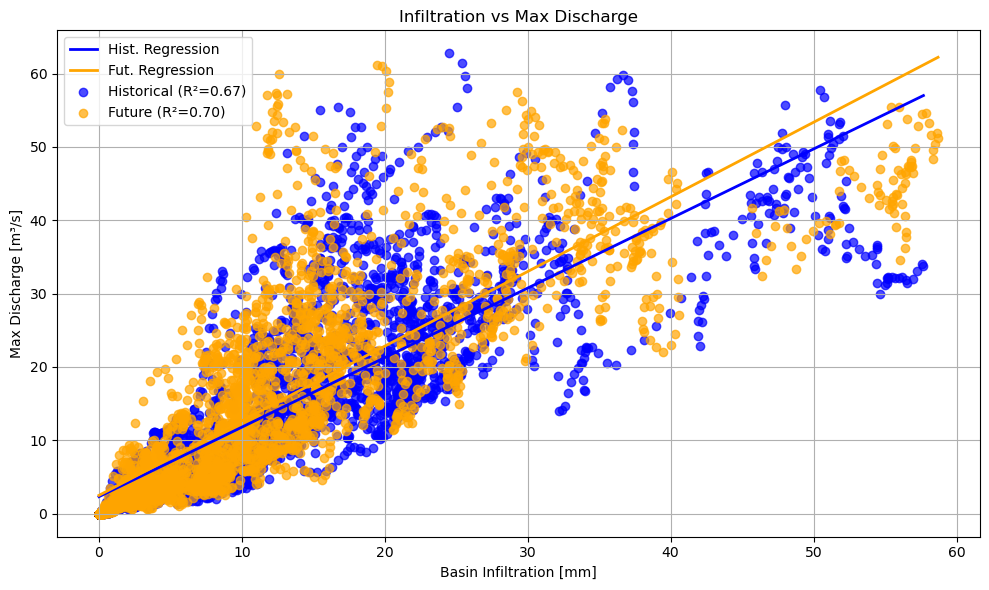

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd

# Define column names
infil_hist = ('historical', 'basin infiltration', 'area_weighted_infiltration_mm')
infil_fut = ('future', 'basin infiltration', 'area_weighted_infiltration_mm')

qmax_hist = ('historical', 'basin discharge', 'max_discharge')
qmax_fut = ('future', 'basin discharge', 'max_discharge')

# Extract and clean historical data
x_hist = final_results_df[infil_hist]
y_hist = final_results_df[qmax_hist]
mask_hist = (~x_hist.isna()) & (~y_hist.isna())
x_hist_clean, y_hist_clean = x_hist[mask_hist], y_hist[mask_hist]

# Extract and clean future data
x_fut = final_results_df[infil_fut]
y_fut = final_results_df[qmax_fut]
mask_fut = (~x_fut.isna()) & (~y_fut.isna())
x_fut_clean, y_fut_clean = x_fut[mask_fut], y_fut[mask_fut]

# Perform linear regressions
slope_hist, intercept_hist, r_hist, _, _ = linregress(x_hist_clean, y_hist_clean)
slope_fut, intercept_fut, r_fut, _, _ = linregress(x_fut_clean, y_fut_clean)
r2_hist = r_hist**2
r2_fut = r_fut**2

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_hist_clean, y_hist_clean, label=f'Historical (R²={r2_hist:.2f})', color='blue', alpha=0.7)
plt.scatter(x_fut_clean, y_fut_clean, label=f'Future (R²={r2_fut:.2f})', color='orange', alpha=0.7)

# Add regression lines
x_range_hist = pd.Series(sorted(x_hist_clean.unique()))
x_range_fut = pd.Series(sorted(x_fut_clean.unique()))
plt.plot(x_range_hist, slope_hist * x_range_hist + intercept_hist, color='blue', linewidth=2, label='Hist. Regression')
plt.plot(x_range_fut, slope_fut * x_range_fut + intercept_fut, color='orange', linewidth=2, label='Fut. Regression')

# Axis labels and formatting
plt.xlabel('Basin Infiltration [mm]')
plt.ylabel('Max Discharge [m³/s]')
plt.title('Infiltration vs Max Discharge')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
